In [4]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

sys.path.insert(0, '..')  # dataset.py lives one level up, shared across experiment types
import dataset
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import model as model_module
import numpy as np
import pandas as pd
import torch
import train as train_module
from sklearn.metrics import confusion_matrix

from investalyze.analysis import encodings
from investalyze.ingest import storage

plt.rcParams['figure.dpi'] = 130

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
TICKERS = 2000  # list[str] of specific tickers, int for a random sample of that many, or None for all
UNIVERSE = None  # name of a universe saved by the ticker selector app (data/universes/<name>.csv); overrides TICKERS when set
EXCLUDE_TICKERS = [
    'LITX',
    'PCG-PD',
    'LIFE',
    'AKRE',
    'BOBS',
    'BKMI',
    'QBTZ',
    'XWIN',
    'SHAZ',
    'OPENL',
    'HOYY',
    'JBS',
    'NSIT',
]  # tickers to always leave out, regardless of TICKERS or UNIVERSE
SEED = 0  # used when TICKERS is an int, and when VALID_METHOD is 'random'
WINDOW_LENGTH = 40
STRIDE = 5

VALID_FRAC = 0.3
VALID_METHOD = 'random'  # 'recent' = time-based (no leakage) / 'random' = random per-window
TEST_N = 1  # always recent: the last N windows of each ticker

ENCODER = encodings.zscore  # swap by hand: RebaseTo100 / RebaseTo1 / encodings.zscore / encodings.minmax
# ENCODER = encodings.minmax  # swap by hand: RebaseTo100 / RebaseTo1 / encodings.zscore / encodings.minmax
BATCH_SIZE = 1024 * 12
EPOCHS = 30
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

HIDDEN = 64
DROPOUT = 0.05
N_BLOCKS = 10  # residual conv blocks (skip connection per block)
KERNEL_START = 3  # kernel size of the stem conv + first residual blocks
KERNEL_END = 9  # kernel size reached by the last residual block (quadratic ramp, odd sizes only)

LR = 1e-3
LR_FACTOR = 0.5  # ReduceLROnPlateau: multiply lr by this on plateau
LR_PATIENCE = 100  # ReduceLROnPlateau: epochs of no valid_loss improvement before reducing lr
LR_METRIC = 'valid'  # 'valid' normally / 'train' when deliberately overfitting to sanity-check capacity

EARLY_STOP_PATIENCE = 100000000000000000000000  # stop if valid_loss hasn't improved in this many epochs
EVAL_CHECKPOINT = 'valid_loss'  # 'last' / 'train_loss' / 'valid_loss' / 'train_acc' / 'valid_acc'

In [6]:
DATA_ROOT = Path('../../data')

con = storage.connect(DATA_ROOT, read_only=True)
if UNIVERSE is not None:
    tickers = [t for t in dataset.load_universe(UNIVERSE, DATA_ROOT) if t not in EXCLUDE_TICKERS]
elif isinstance(TICKERS, int):
    tickers = dataset.sample_tickers(con, TICKERS, seed=SEED, exclude=EXCLUDE_TICKERS)
else:
    tickers = TICKERS
series = dataset.get_ohlcv_series(con, tickers, exclude=EXCLUDE_TICKERS)
con.close()
print('tickers used', tickers if tickers is not None else 'ALL')

channels, meta = dataset.build_windows(series, window_length=WINDOW_LENGTH, stride=STRIDE)
print('windows', meta.shape[0], 'across', meta['Ticker'].nunique(), 'tickers')

tickers used ['AA', 'AACB', 'AACIU', 'AAPG', 'AAPL', 'AARD', 'AB', 'ABFL', 'ABLG', 'ABLS', 'ABLVW', 'ABOT', 'ABR-PE', 'ABSI', 'ABTC', 'ABUF', 'ABUS', 'ABVX', 'ACA', 'ACB', 'ACEL', 'ACI', 'ACIW', 'ACLX', 'ACMR', 'ACNT', 'ACOG', 'ACON', 'ACP-PA', 'ACR', 'ACRV', 'ACT', 'ACTG', 'ADAC', 'ADAM', 'ADAMG', 'ADCT', 'ADIL', 'AEAQU', 'AEE', 'AEFC', 'AEG', 'AEIS', 'AEON', 'AESI', 'AFBI', 'AFGD', 'AFGE', 'AFJKU', 'AFL', 'AGH', 'AGI', 'AGNCO', 'AGNT', 'AGRZ', 'AGYS', 'AHL-PF', 'AIBD', 'AIDX', 'AIG', 'AIIOW', 'AIMD', 'AIO', 'AIR', 'AIRG', 'AIRO', 'AIRTP', 'AIUP', 'AIV', 'AKAM', 'AKBA', 'ALAB', 'ALAR', 'ALB-PA', 'ALC', 'ALCO', 'ALDFU', 'ALDX', 'ALHC', 'ALLT', 'ALRS', 'ALSN', 'ALTG', 'ALVO', 'ALVOW', 'AM', 'AMAL', 'AMBA', 'AME', 'AMH-PG', 'AMH-PH', 'AMIX', 'AMJB', 'AMTB', 'AMTM', 'AMYY', 'AMZW', 'ANAB', 'ANG-PD', 'ANGI', 'ANY', 'AON', 'AOUT', 'AP', 'APG', 'API', 'APLD', 'APO-PA', 'APPN', 'APT', 'APTV', 'APVO', 'APWC', 'APXTU', 'AQLT', 'AQN', 'AQST', 'ARAI', 'ARCT', 'ARDC', 'ARDX', 'AREC', 'ARHS', 'ARR-

In [7]:
train_mask, valid_mask, test_mask = dataset.split_windows(meta, valid_frac=VALID_FRAC, valid_method=VALID_METHOD, test_n=TEST_N, seed=SEED)

labels, tickers_sorted = dataset.encode_labels(meta, train_mask)
n_classes = len(tickers_sorted)

print('train windows', int(train_mask.sum()), 'valid windows', int(valid_mask.sum()), 'test windows', int(test_mask.sum()))
pd.Series(labels[train_mask]).value_counts().sort_index()

train windows 791709 valid windows 339112 test windows 1792


0       2261
1         27
2       1597
3         34
4       1311
        ... 
1787     223
1788      13
1789     448
1790     753
1791     482
Name: count, Length: 1792, dtype: int64

In [8]:
X = dataset.encode_windows(channels, ENCODER)
X_train, y_train = X[train_mask], labels[train_mask]
X_valid, y_valid = X[valid_mask], labels[valid_mask]
X_test, y_test = X[test_mask], labels[test_mask]

weights = dataset.class_weights(y_train, n_classes)
train_loader = train_module.make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = train_module.make_loader(X_valid, y_valid, batch_size=BATCH_SIZE, shuffle=False)
test_loader = train_module.make_loader(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

In [9]:
net = model_module.OHLCVClassifierCNN(
    n_channels=5,
    n_classes=n_classes,
    hidden=HIDDEN,
    dropout=DROPOUT,
    n_blocks=N_BLOCKS,
    kernel_start=KERNEL_START,
    kernel_end=KERNEL_END,
).to(DEVICE)
optimizer = torch.optim.Adam(net.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE)
history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}
best = train_module.new_best_tracker()

In [10]:
net

OHLCVClassifierCNN(
  (stem): Sequential(
    (0): Conv1d(5, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout1d(p=0.05, inplace=False)
  )
  (blocks): Sequential(
    (0): _ResConvBlock(
      (net): Sequential(
        (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout1d(p=0.05, inplace=False)
      )
    )
    (1): _ResConvBlock(
      (net): Sequential(
        (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout1d(p=0.05, inplace=False)
      )
    )
    (2): _ResConvBlock(
      (net): Sequential(
        (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
   

In [11]:
CHANGE_LR = False  # set True (and NEW_LR below), then run this cell to change lr mid-training
NEW_LR = 0.1

if CHANGE_LR:
    for g in optimizer.param_groups:
        g['lr'] = NEW_LR
print(f'lr = {optimizer.param_groups[0]["lr"]:.2e}')

lr = 1.00e-03


In [12]:
print(f'Baseline loss: {np.log(n_classes):.4f} | acc: {1 / n_classes:.4f}')

# re-run this cell (unchanged) to keep training the same net/optimizer for EPOCHS more
history, best = train_module.train_model(
    net,
    train_loader,
    valid_loader,
    optimizer,
    epochs=EPOCHS,
    class_weights=weights,
    n_classes=n_classes,
    device=DEVICE,
    history=history,
    scheduler=scheduler,
    scheduler_metric=LR_METRIC,
    best=best,
    early_stop_patience=EARLY_STOP_PATIENCE,
)

Baseline loss: 7.4911 | acc: 0.0006
epoch 1/30  train_loss=7.4925 valid_loss=7.4791 train_acc=0.0009 valid_acc=0.0009 lr=1.00e-03 (t:1/1 - v:1/1)
epoch 2/30  train_loss=7.3677 valid_loss=7.2617 train_acc=0.0013 valid_acc=0.0020 lr=1.00e-03 (t:2/2 - v:2/2)
epoch 3/30  train_loss=7.1177 valid_loss=7.1633 train_acc=0.0022 valid_acc=0.0025 lr=1.00e-03 (t:3/3 - v:3/3)
epoch 4/30  train_loss=6.9005 valid_loss=6.8995 train_acc=0.0032 valid_acc=0.0033 lr=1.00e-03 (t:4/4 - v:4/4)
epoch 5/30  train_loss=6.7615 valid_loss=6.6980 train_acc=0.0038 valid_acc=0.0052 lr=1.00e-03 (t:5/5 - v:5/5)
epoch 6/30  train_loss=6.6539 valid_loss=6.5816 train_acc=0.0047 valid_acc=0.0058 lr=1.00e-03 (t:6/6 - v:6/6)
epoch 7/30  train_loss=6.5751 valid_loss=6.5114 train_acc=0.0053 valid_acc=0.0077 lr=1.00e-03 (t:7/7 - v:7/7)
epoch 8/30  train_loss=6.5088 valid_loss=6.7287 train_acc=0.0067 valid_acc=0.0047 lr=1.00e-03 (t:8/8 - v:7/7)
epoch 9/30  train_loss=6.4486 valid_loss=6.5734 train_acc=0.0079 valid_acc=0.0066 lr

In [22]:
for metric_name, info in best.items():
    print(f'best {metric_name}: epoch {info["epoch"] + 1}  value={info["value"]:.4f}')

best train_loss: epoch 30  value=5.6077
best valid_loss: epoch 29  value=5.6424
best train_acc: epoch 30  value=0.0705
best valid_acc: epoch 29  value=0.0635


In [23]:
# minmax
# best train_loss: epoch 150  value=3.9503
# best valid_loss: epoch 128  value=4.1035
# best train_acc: epoch 144  value=0.0615
# best valid_acc: epoch 146  value=0.0447

# RebaseTo1
# best train_loss: epoch 150  value=3.8409
# best valid_loss: epoch 137  value=3.9027
# best train_acc: epoch 143  value=0.0495
# best valid_acc: epoch 132  value=0.0463

# zscore
# best train_loss: epoch 150  value=3.6506
# best valid_loss: epoch 146  value=3.8188
# best train_acc: epoch 123  value=0.0850
# best valid_acc: epoch 139  value=0.0730


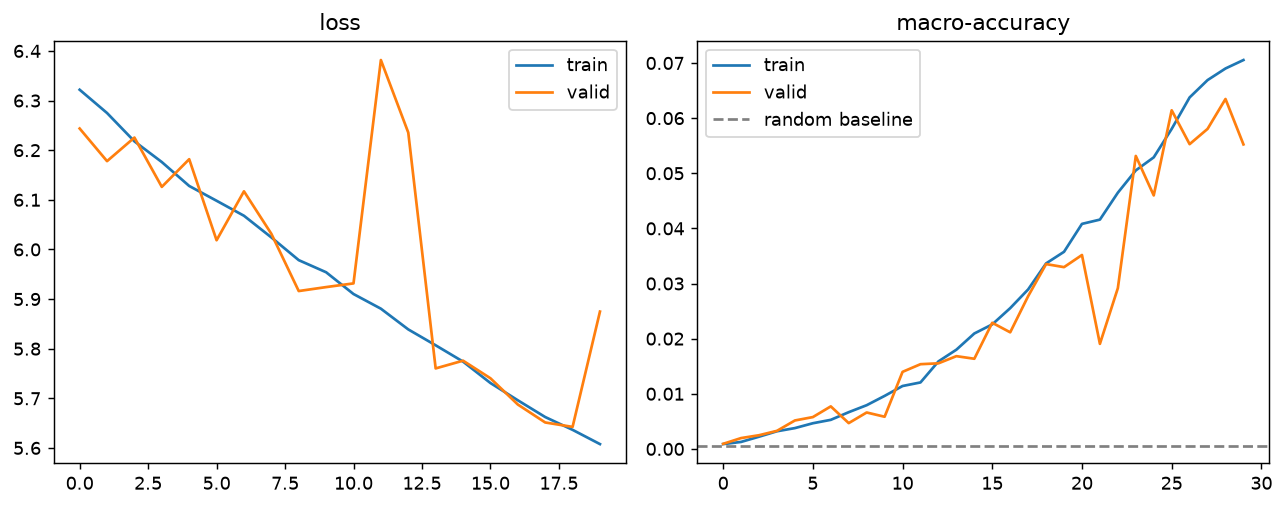

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history['train_loss'][10:], label='train')
axes[0].plot(history['valid_loss'][10:], label='valid')
axes[0].set_title('loss')
axes[0].legend()
axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['valid_acc'], label='valid')
axes[1].axhline(1 / n_classes, color='gray', linestyle='--', label='random baseline')
axes[1].set_title('macro-accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

In [25]:
if EVAL_CHECKPOINT != 'last':
    ckpt = best[EVAL_CHECKPOINT]
    net.load_state_dict(ckpt['state'])
    print(f'loaded {EVAL_CHECKPOINT} checkpoint from epoch {ckpt["epoch"] + 1}  value={ckpt["value"]:.4f}')
else:
    print('using last-epoch weights')

loaded valid_loss checkpoint from epoch 29  value=5.6424


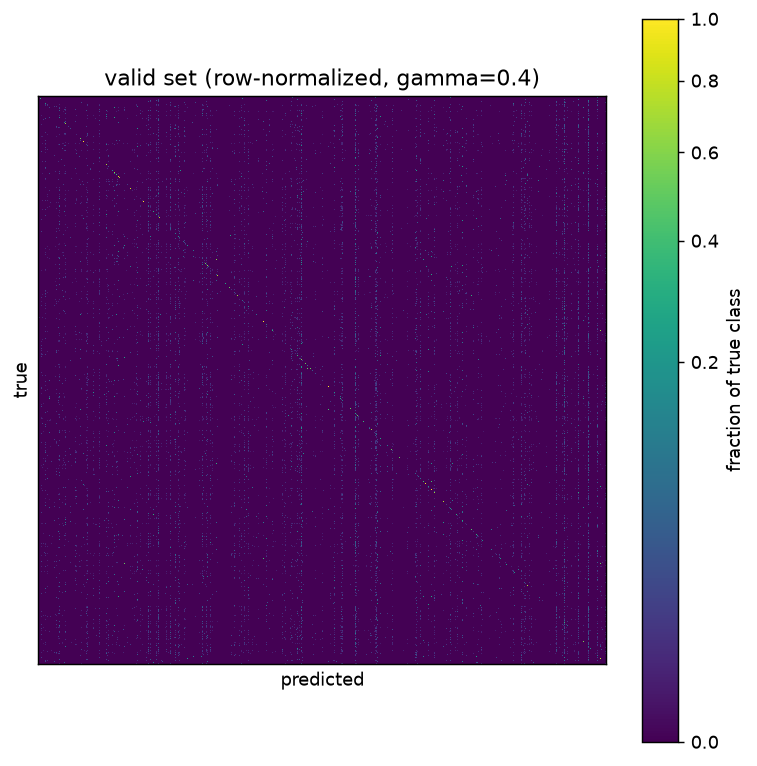

In [26]:
valid_preds, valid_true = train_module.predict(net, valid_loader, DEVICE)
cm_valid = confusion_matrix(valid_true, valid_preds, labels=range(n_classes))
row_sums = cm_valid.sum(axis=1, keepdims=True)
cm_valid_norm = np.divide(cm_valid, row_sums, out=np.zeros_like(cm_valid, dtype=float), where=row_sums != 0)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm_valid_norm, cmap='viridis', norm=mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=1), interpolation='nearest')
if n_classes <= 40:
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels(tickers_sorted, rotation=90)
    ax.set_yticks(range(n_classes))
    ax.set_yticklabels(tickers_sorted)
else:
    ax.set_xticks([])
    ax.set_yticks([])
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('valid set (row-normalized, gamma=0.4)')
plt.colorbar(im, label='fraction of true class')
plt.tight_layout()
plt.show()

In [27]:
cm_valid_offdiag = cm_valid.copy()
np.fill_diagonal(cm_valid_offdiag, 0)
i_idx, j_idx = np.nonzero(cm_valid_offdiag)
counts = cm_valid_offdiag[i_idx, j_idx]
order = np.argsort(-counts)[:15]
valid_pairs = [(tickers_sorted[i], tickers_sorted[j], int(c)) for i, j, c in zip(i_idx[order], j_idx[order], counts[order])]
valid_pairs

[('BA', 'AA', 239),
 ('IP', 'AA', 200),
 ('PG', 'AA', 179),
 ('XOM', 'AA', 178),
 ('FT', 'PPT', 176),
 ('TRN', 'AA', 169),
 ('IBM', 'AA', 161),
 ('MHF', 'PPT', 160),
 ('CVX', 'AA', 158),
 ('SPGI', 'AA', 147),
 ('HAL', 'AA', 135),
 ('JMM', 'PPT', 134),
 ('MGEE', 'PPT', 133),
 ('WY', 'AA', 130),
 ('BDX', 'AA', 127)]

test accuracy=0.009  macro-accuracy=0.009


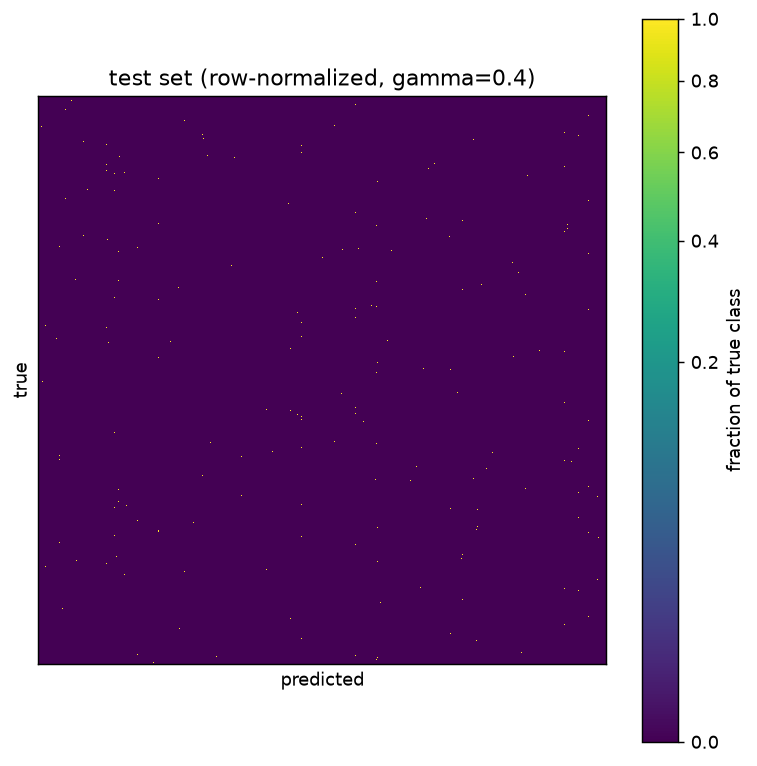

In [28]:
preds, y_true = train_module.predict(net, test_loader, DEVICE)
test_acc = (preds == y_true).mean()
test_macro_acc = train_module.macro_accuracy(torch.tensor(preds), torch.tensor(y_true), n_classes)
print(f'test accuracy={test_acc:.3f}  macro-accuracy={test_macro_acc:.3f}')
cm = confusion_matrix(y_true, preds, labels=range(n_classes))
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm_norm, cmap='viridis', norm=mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=1), interpolation='nearest')
if n_classes <= 40:
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels(tickers_sorted, rotation=90)
    ax.set_yticks(range(n_classes))
    ax.set_yticklabels(tickers_sorted)
else:
    ax.set_xticks([])
    ax.set_yticks([])
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('test set (row-normalized, gamma=0.4)')
plt.colorbar(im, label='fraction of true class')
plt.tight_layout()
plt.show()

In [29]:
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
i_idx, j_idx = np.nonzero(cm_offdiag)
counts = cm_offdiag[i_idx, j_idx]
order = np.argsort(-counts)[:150]
pairs = [(tickers_sorted[i], tickers_sorted[j], int(c)) for i, j, c in zip(i_idx[order], j_idx[order], counts[order])]
pairs

[('AA', 'BMNR', 1),
 ('AAPG', 'CARD', 1),
 ('AAPL', 'BEPC', 1),
 ('AARD', 'TRDA', 1),
 ('AB', 'NWN', 1),
 ('ABFL', 'BVAL', 1),
 ('ABLG', 'SEPP', 1),
 ('ABLS', 'DRES', 1),
 ('ABOT', 'JDVL', 1),
 ('ABR-PE', 'BMN', 1),
 ('ABSI', 'RZLV', 1),
 ('ABTC', 'LU', 1),
 ('ABUS', 'SYM', 1),
 ('ABVX', 'AQN', 1),
 ('ACA', 'JXN', 1),
 ('ACB', 'SLDE', 1),
 ('ACEL', 'PBR', 1),
 ('ACI', 'EOS', 1),
 ('ACIW', 'NG', 1),
 ('ACLX', 'BMN', 1),
 ('ACMR', 'ALC', 1),
 ('ACNT', 'HOFT', 1),
 ('ACOG', 'FPH', 1),
 ('ACON', 'NMG', 1),
 ('ACP-PA', 'BGM', 1),
 ('ACR', 'MEGI', 1),
 ('ACRV', 'USGG', 1),
 ('ACT', 'UE', 1),
 ('ACTG', 'GLUE', 1),
 ('ADAM', 'JXN', 1),
 ('ADAMG', 'MFAO', 1),
 ('ADCT', 'INSG', 1),
 ('ADIL', 'STI', 1),
 ('AEE', 'BAM', 1),
 ('AEFC', 'MEGI', 1),
 ('AEG', 'NEMG', 1),
 ('AEIS', 'BTCI', 1),
 ('AEON', 'EAI', 1),
 ('AESI', 'PSA-PR', 1),
 ('AFBI', 'GJS', 1),
 ('AFGD', 'FTNJ', 1),
 ('AFGE', 'AMYY', 1),
 ('AFL', 'BTX', 1),
 ('AGH', 'CRMX', 1),
 ('AGI', 'KLAG', 1),
 ('AGNCO', 'PPT', 1),
 ('AGNT', 'AA', 1),

In [30]:
def worst_predicted(cm_offdiag, top=20):
    fp_counts = cm_offdiag.sum(axis=0)  # column sums: how often each ticker is wrongly predicted
    n_sources = (cm_offdiag > 0).sum(axis=0)  # distinct true tickers wrongly predicted as this one
    order = np.argsort(-fp_counts)[:top]
    return order, fp_counts, n_sources


for name, offdiag in [('valid', cm_valid_offdiag), ('test', cm_offdiag)]:
    order, fp_counts, n_sources = worst_predicted(offdiag)
    print(f'{name}:')
    for idx in order:
        pct_sources = n_sources[idx] / n_classes * 100
        print(
            f'  {tickers_sorted[idx]:>8}  wrongly predicted {int(fp_counts[idx])} times, '
            f'from {int(n_sources[idx])} different tickers ({pct_sources:.1f}% of all tickers)'
        )
    print()

valid:
        AA  wrongly predicted 16229 times, from 884 different tickers (49.3% of all tickers)
      BEPC  wrongly predicted 9702 times, from 739 different tickers (41.2% of all tickers)
      MEGI  wrongly predicted 7858 times, from 786 different tickers (43.9% of all tickers)
       GHC  wrongly predicted 7334 times, from 716 different tickers (40.0% of all tickers)
      WLYB  wrongly predicted 7197 times, from 940 different tickers (52.5% of all tickers)
       FMX  wrongly predicted 7089 times, from 764 different tickers (42.6% of all tickers)
       SFD  wrongly predicted 6830 times, from 692 different tickers (38.6% of all tickers)
      IYRI  wrongly predicted 5590 times, from 645 different tickers (36.0% of all tickers)
        BA  wrongly predicted 4796 times, from 728 different tickers (40.6% of all tickers)
       PPT  wrongly predicted 4131 times, from 466 different tickers (26.0% of all tickers)
      RLTY  wrongly predicted 4018 times, from 746 different tickers (41